Mounted at /content/drive


/tmp/ipykernel_3774/850405049.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("class").apply(



Random Forest Accuracy: 0.914
              precision    recall  f1-score   support

    car_horn       0.93      0.93      0.93        14
  jackhammer       0.89      1.00      0.94         8
       siren       0.92      0.85      0.88        13

    accuracy                           0.91        35
   macro avg       0.91      0.92      0.92        35
weighted avg       0.92      0.91      0.91        35



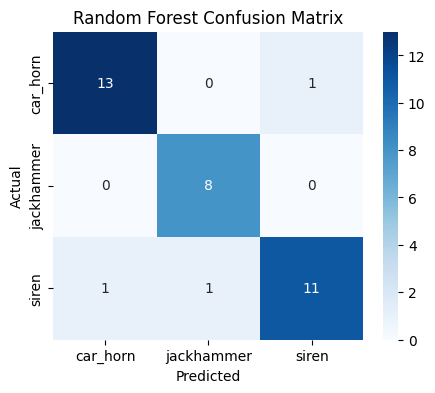


SVM Accuracy: 0.914
              precision    recall  f1-score   support

    car_horn       0.82      1.00      0.90        14
  jackhammer       1.00      0.75      0.86         8
       siren       1.00      0.92      0.96        13

    accuracy                           0.91        35
   macro avg       0.94      0.89      0.91        35
weighted avg       0.93      0.91      0.91        35



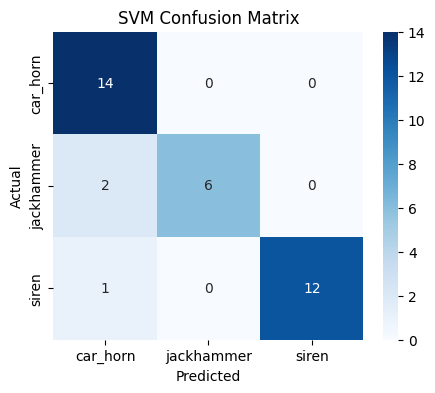

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.5693 - loss: 1.0369
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.7445 - loss: 0.6810
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8102 - loss: 0.5312
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.8394 - loss: 0.4146
Epoch 5/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9270 - loss: 0.2857
Epoch 6/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.9270 - loss: 0.1983
Epoch 7/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9343 - loss: 0.1825
Epoch 8/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9927 - loss: 0.1001
Epoch 9/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9927 - loss: 0.0847
Epoch 10/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 1.0000 - loss: 0.0377
Epoch 11/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 1.0000 - loss: 0.0159
Epoch 12/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 1.0000 - loss: 0.0

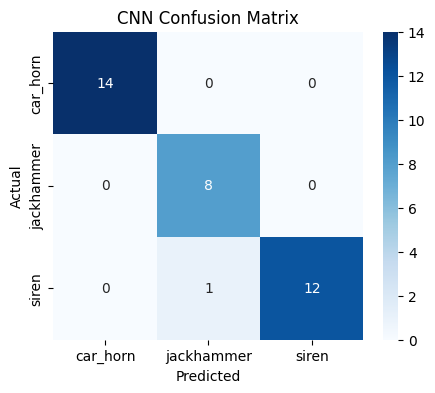

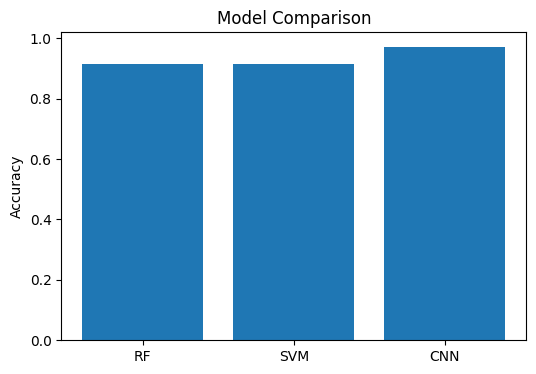

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3a9907e19d40a7b8d8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [2]:
# =========================
# 🚀 1. Setup
# =========================
from google.colab import drive
drive.mount('/content/drive')

!pip install -q librosa seaborn scikit-learn gradio tensorflow

# =========================
# 📦 Imports
# =========================
import pandas as pd
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# =========================
# 🔒 Reproducibility
# =========================
tf.random.set_seed(42)
np.random.seed(42)

# =========================
# 📂 Load Dataset
# =========================
base_path = "/content/drive/MyDrive/Mini project/archive (1)/"

metadata = pd.read_csv(
    os.path.join(base_path, "UrbanSound8K.csv")
)

classes = ["car_horn", "jackhammer", "siren"]

data = metadata[metadata["class"].isin(classes)].copy()

# balanced dataset
data = data.groupby("class").apply(
    lambda x: x.sample(n=70, random_state=42)
).reset_index(drop=True)

# file paths
data["file_path"] = data.apply(
    lambda x: os.path.join(
        base_path,
        f"fold{x.fold}",
        x.slice_file_name
    ),
    axis=1
)

# remove missing files
data = data[data["file_path"].apply(os.path.exists)]

# =========================
# ⚡ Feature Extraction
# =========================
def extract_features(file_path):

    try:
        audio, sr = librosa.load(
            file_path,
            duration=1.5
        )

        # MFCC
        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=20
        )

        mfcc = np.mean(mfcc.T, axis=0)

        # EXTRA FEATURES
        chroma = np.mean(
            librosa.feature.chroma_stft(
                y=audio,
                sr=sr
            )
        )

        spectral_centroid = np.mean(
            librosa.feature.spectral_centroid(
                y=audio,
                sr=sr
            )
        )

        rolloff = np.mean(
            librosa.feature.spectral_rolloff(
                y=audio,
                sr=sr
            )
        )

        return np.hstack([
            mfcc,
            chroma,
            spectral_centroid,
            rolloff
        ])

    except:
        return None

# =========================
# 📊 Prepare ML Data
# =========================
X = []
y = []

for _, row in data.iterrows():

    feat = extract_features(row["file_path"])

    if feat is not None:
        X.append(feat)
        y.append(row["class"])

X = np.array(X)
y = np.array(y)

# normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 🌲 Random Forest
# =========================
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# =========================
# 🔵 SVM
# =========================
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True
)

svm_model.fit(X_train, y_train)

# =========================
# 📊 Evaluation Function
# =========================
def evaluate(model, name):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name} Accuracy: {acc:.3f}")

    print(classification_report(
        y_test,
        y_pred
    ))

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=classes
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    return acc

# evaluate ML models
rf_acc = evaluate(rf_model, "Random Forest")
svm_acc = evaluate(svm_model, "SVM")

# =========================
# 🧠 CNN Feature Extraction
# =========================
def extract_mel(file_path, max_len=64):

    audio, sr = librosa.load(
        file_path,
        duration=1.5
    )

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128,
        fmax=8000
    )

    mel = librosa.power_to_db(mel)

    # normalize
    mel = (
        mel - np.mean(mel)
    ) / (
        np.std(mel) + 1e-6
    )

    # padding
    if mel.shape[1] < max_len:

        mel = np.pad(
            mel,
            ((0,0), (0,max_len-mel.shape[1]))
        )

    else:
        mel = mel[:, :max_len]

    return mel

# =========================
# 📦 Prepare CNN Data
# =========================
X_cnn = []
y_cnn = []

label_map = {
    c:i for i,c in enumerate(classes)
}

for _, row in data.iterrows():

    mel = extract_mel(row["file_path"])

    if mel is not None:
        X_cnn.append(mel)
        y_cnn.append(
            label_map[row["class"]]
        )

X_cnn = np.array(X_cnn)[..., np.newaxis]
y_cnn = np.array(y_cnn)

# split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn
)

# =========================
# 🧠 Improved CNN Model
# =========================
cnn_model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        16,
        (3,3),
        activation='relu',
        input_shape=Xc_train.shape[1:]
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    # EXTRA CNN LAYER
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        len(classes),
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 🚀 Train CNN
# =========================
cnn_model.fit(
    Xc_train,
    yc_train,
    epochs=25,
    batch_size=16,
    verbose=1
)

# =========================
# 📊 CNN Evaluation
# =========================
y_pred_cnn = np.argmax(
    cnn_model.predict(Xc_test),
    axis=1
)

cnn_acc = accuracy_score(
    yc_test,
    y_pred_cnn
)

print(f"\nCNN Accuracy: {cnn_acc:.3f}")

cm_cnn = confusion_matrix(
    yc_test,
    y_pred_cnn
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =========================
# 📈 Model Comparison
# =========================
plt.figure(figsize=(6,4))

plt.bar(
    ["RF", "SVM", "CNN"],
    [rf_acc, svm_acc, cnn_acc]
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

# =========================
# 🎧 Audio Classification
# =========================
def classify_audio(file, model_name):

    if file is None:
        return "Upload audio file"

    # CNN
    if model_name == "CNN":

        mel = extract_mel(file)

        mel = mel[np.newaxis, ..., np.newaxis]

        probs = cnn_model.predict(mel)[0]

        pred_class = classes[np.argmax(probs)]

        confidence = np.max(probs) * 100

        return f"{pred_class} ({confidence:.2f}%)"

    # RF / SVM
    feat = extract_features(file)

    if feat is None:
        return "Error processing audio"

    feat = scaler.transform(
        feat.reshape(1, -1)
    )

    model = (
        rf_model
        if model_name == "RF"
        else svm_model
    )

    pred = model.predict(feat)[0]

    confidence = np.max(
        model.predict_proba(feat)
    ) * 100

    return f"{pred} ({confidence:.2f}%)"

# =========================
# 🎨 Gradio UI
# =========================
with gr.Blocks() as app:

    gr.Markdown(
        "# Urban Noise Classification"
    )

    audio = gr.Audio(type="filepath")

    model_choice = gr.Radio(
        ["RF", "SVM", "CNN"],
        value="CNN"
    )

    output = gr.Textbox()

    btn = gr.Button("Classify")

    btn.click(
        classify_audio,
        inputs=[audio, model_choice],
        outputs=output
    )

app.launch(share=True)